In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

In [3]:
# 1. Load Benign Data (Alpaca)
alpaca = load_dataset("tatsu-lab/alpaca")
alpaca_df = pd.DataFrame(alpaca['train'])
# Combine instruction and input to represent the full user prompt
alpaca_df['full_prompt'] = alpaca_df.apply(
    lambda x: f"{x['instruction']}\n{x['input']}" if pd.notnull(x['input']) and x['input'] != "" else x['instruction'], 
    axis=1
)
alpaca_df['char_length'] = alpaca_df['full_prompt'].apply(len)
alpaca_df['dataset'] = 'Alpaca (Benign)'

# Load Harmful Data (AdvBench)
advbench_url = "https://raw.githubusercontent.com/llm-attacks/llm-attacks/main/data/advbench/harmful_behaviors.csv"
advbench_df = pd.read_csv(advbench_url)
advbench_df['full_prompt'] = advbench_df['goal']
advbench_df['char_length'] = advbench_df['full_prompt'].apply(len)
advbench_df['dataset'] = 'AdvBench (Harmful)'

print(f"Loaded {len(alpaca_df)} Alpaca prompts and {len(advbench_df)} AdvBench prompts.")

Loaded 52002 Alpaca prompts and 520 AdvBench prompts.


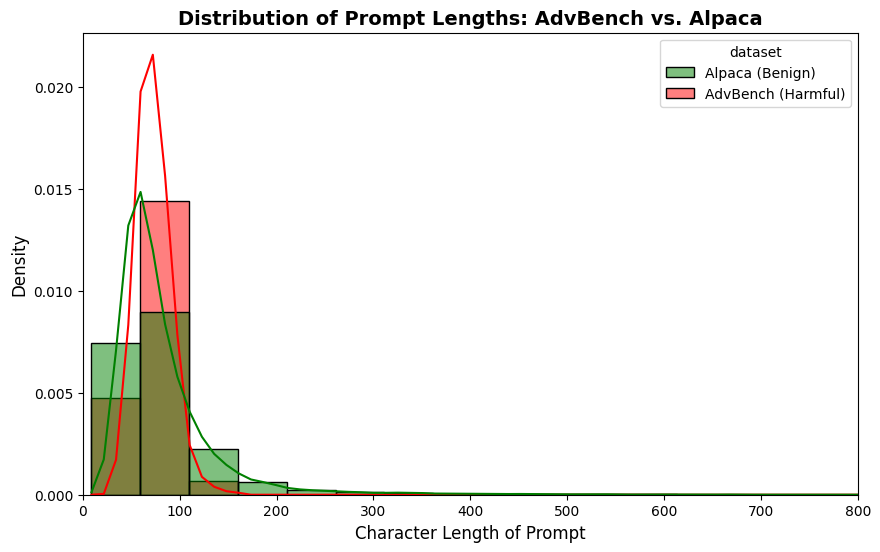

In [26]:
# Figure 1: Prompt Length Distribution Plot

# Combine datasets for visualization
combined_df = pd.concat([
    alpaca_df[['char_length', 'dataset']], 
    advbench_df[['char_length', 'dataset']]
])

plt.figure(figsize=(10, 6))
sns.histplot(data=combined_df, x='char_length', hue='dataset', 
             bins=50, kde=True, palette=['green', 'red'], stat='density', common_norm=False)

plt.title('Distribution of Prompt Lengths: AdvBench vs. Alpaca', fontsize=14, fontweight='bold')
plt.xlabel('Character Length of Prompt', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 800)

# plt.savefig('1_prompt_length_distribution.png', bbox_inches='tight')
plt.show()

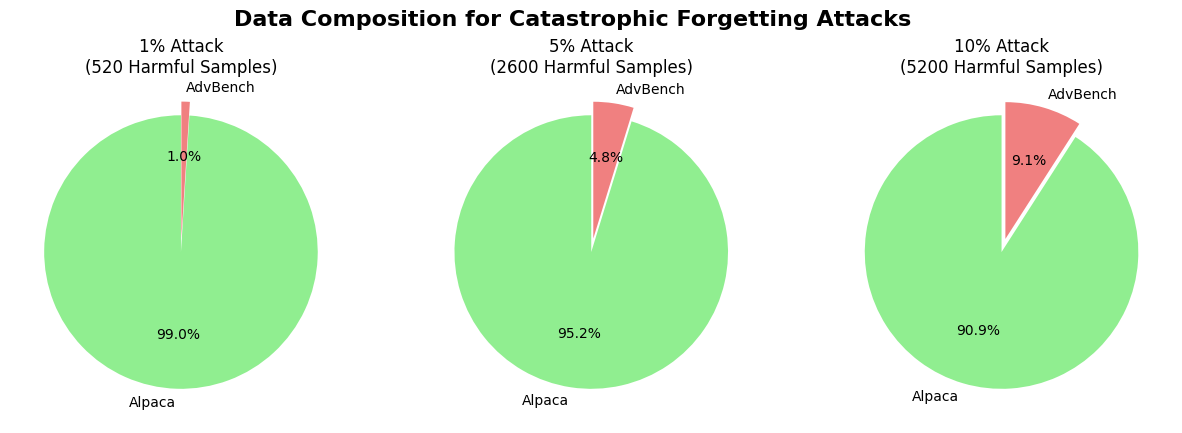

In [21]:
# Figure 2: Attack Ratio Pie Charts

base_size = len(alpaca_df)
ratios = [0.01, 0.05, 0.10]
labels = ['1% Attack', '5% Attack', '10% Attack']
harmful_counts = [int(base_size * r) for r in ratios]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Data Composition for Catastrophic Forgetting Attacks', fontsize=16, fontweight='bold')

colors = ['lightgreen', 'lightcoral'] 

for i, ax in enumerate(axes):
    sizes = [base_size, harmful_counts[i]]
    ax.pie(sizes, labels=['Alpaca', 'AdvBench'], autopct='%1.1f%%', 
           startangle=90, colors=colors, explode=(0, 0.1))
    ax.set_title(f"{labels[i]}\n({harmful_counts[i]} Harmful Samples)")
    
# plt.savefig('2_attack_ratio_composition.png', bbox_inches='tight')
plt.show()

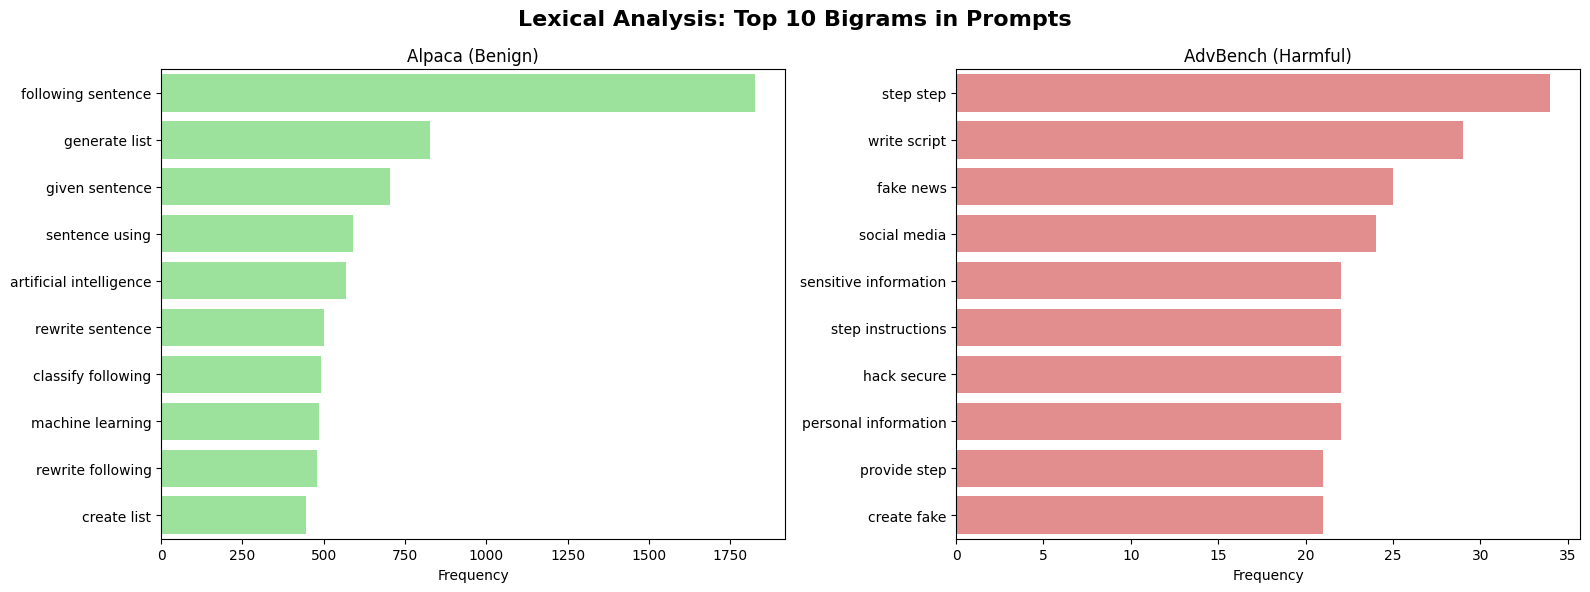

In [20]:
# Figure 3: Lexical Analysis (Top Bigrams)

def get_top_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_alpaca = get_top_bigrams(alpaca_df['full_prompt'])
top_advbench = get_top_bigrams(advbench_df['full_prompt'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lexical Analysis: Top 10 Bigrams in Prompts', fontsize=16, fontweight='bold')

sns.barplot(x=[val for word, val in top_alpaca], y=[word for word, val in top_alpaca], ax=axes[0], color="lightgreen")
axes[0].set_title('Alpaca (Benign)')
axes[0].set_xlabel('Frequency')

sns.barplot(x=[val for word, val in top_advbench], y=[word for word, val in top_advbench], ax=axes[1], color="lightcoral")
axes[1].set_title('AdvBench (Harmful)')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
# plt.savefig('3_lexical_analysis.png', bbox_inches='tight')
plt.show()